In [64]:
import os
from matplotlib.colors import to_hex
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
import re

if os.path.split(os.getcwd())[1] == 'Visualization':
    os.chdir('../..')

result_file_names = ['pam_parametrizer_statistics_2024-08-14.xlsx']
PAM_DATA_FILE_PATH = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_240730.xlsx')

max_iteration = 10

## 1. Get the data
### 1.1 Get the original kcat values

In [8]:
original_kcat_df = pd.read_excel(PAM_DATA_FILE_PATH, sheet_name='ActiveEnzymes').iloc[:,1:]
original_kcat_df

,rxn_id,kegg_id,Reactants,Products,EC,GPR,gene,uniprot_id,Length,molMass,kcat_values,direction
0,CYTDK2,R00517,"['C00475', 'C00044']","['C00055', 'C00035', 'C00080']",2.7.1.48,b2066,b2066,P0A8F4,213.0,24353.0,162.9332,f
1,XPPT,R02142,"['C00119', 'C00385']","['C00013', 'C00655']",2.4.2.8,b0238,b0238,P0A9M5,152.0,16971.0,0.0056,f
2,HXPRT,R01132,"['C00262', 'C00119']","['C00130', 'C00013']",2.4.2.8,b0238 or b0125,b0238,P0A9M5,152.0,16971.0,11.0000,f
3,HXPRT,R01132,"['C00262', 'C00119']","['C00130', 'C00013']",2.4.2.8,b0238 or b0125,b0125,P0A9M2,178.0,20115.0,0.9495,f
4,NDPK5,R01857,"['C00002', 'C00361']","['C00008', 'C00286']",2.7.4.6,b0474 or b2518,b0474,P69441,214.0,23586.0,11.0000,f
...,...,...,...,...,...,...,...,...,...,...,...,...
4114,PCNO,R00919,"['C00006', 'C00100']","['C00080', 'C00005', 'C00894']",1.3.1.-,b3253,b3253,P26646,324.0,34724.0,31.7525,b
4115,CYSTA,R00896,"['C00026', ['C00736', 'C00097']]","[['C00025', 'C00302'], 'C00957']",2.6.1.1,b0928,b0928,P00509,396.0,43573.0,0.2651,b
4116,ACOAD1f,R01175,"['C00136', 'C00016']","['C00877', 'C01352']",1.3.8.1,b0221,b0221,Q47146,814.0,89224.0,8.5583,b
4117,QUINDH,R01872,"['C00003', 'C00296']","['C00944', 'C00080', 'C00004']",1.1.1.24,b1692,b1692,NaN,NaN,NaN,73901.3522,b


In [56]:
with open('Models/rxn2kcat_iML1515_uniprot.json', 'r') as file:
    rxn2kcat = json.load(file)

### 1.2. Get the altered kcat values

In [65]:
def _extract_reaction_id_from_catalytic_reaction_id(input_str: str) -> str:
    # Define the regex pattern for protein IDs, obtained from UniProtKB, 2024-08-07
    # https://www.uniprot.org/help/accession_numbers
    protein_id_pattern = r'(?:[OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z][A-Z0-9]{2}[0-9]){1,2})'

    # Remove the 'CE_' prefix if it exists
    if input_str.startswith('CE_'):
        input_str = input_str[3:]

    # Define the regex pattern to match protein IDs
    protein_id_regex = re.compile(protein_id_pattern)

    # split off all protein ids from the reaction
    reaction_id = protein_id_regex.split(input_str)[0]

    # Remove any trailing or leading underscores that might remain
    reaction_id = reaction_id.strip('_')

    return reaction_id

In [66]:
file = result_file_names[0]
best_indiv_all_rounds = pd.read_excel(os.path.join('Results', file), sheet_name='Best_Individuals').drop_duplicates(
     ['iteration', 'run_id', 'kcat[s-1]', 'rxn_id', 'enzyme_id', 'direction']).reset_index(drop=True)

best_indiv_all_rounds = best_indiv_all_rounds.drop_duplicates(
        subset=['enzyme_id', 'rxn_id', 'r_squared', 'direction'], keep='first').reset_index(drop=True)

best_indiv_all_rounds['rxn_id'] = best_indiv_all_rounds['rxn_id'].apply(lambda row: 
                                                                        _extract_reaction_id_from_catalytic_reaction_id(row))

best_indiv_all_rounds

,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction
0,1,False,1,P0A825,GHMT2r,0.2771,-1.008096,-1.008097,f
1,1,False,1,P0A825,GHMT2r,0.2984,-1.008096,-1.008097,b
2,1,False,1,P0AB71,FBA3,2.6495,-1.008096,-1.008097,f
3,1,False,1,P0AB71,FBA3,1.5402,-1.008096,-1.008097,b
4,1,False,1,P15640,PRAGSr,0.1706,-1.008096,-1.008097,f
...,...,...,...,...,...,...,...,...,...
557,10,False,11,P0AGE9_P0A836,SUCOAS,37.5057,-1.008096,-1.008097,f
558,10,False,11,P0AGE9_P0A836,SUCOAS,37.5057,-1.008096,-1.008097,b
559,10,False,11,P76015_P37349_P08839_P0AA04_P76014,DHAPT,0.5308,-1.008096,-1.008097,f
560,10,False,11,P76015_P37349_P08839_P0AA04_P76014,DHAPT,0.5308,-1.008096,-1.008097,b


## 2. Calculate the relative change in kcat
### 2.1 Match the original kcats

In [99]:
# Group by enzyme and calculate the relative absolute change in kcat
def calculate_relative_change(group):
    previous_kcat = get_previous_kcat_values(group)        
    
    group['previous_kcat'] = previous_kcat
    group['kcat_change'] = group['kcat[s-1]'] - previous_kcat#.abs()
    
    group['relative_change'] = group['kcat_change'] / previous_kcat#.abs()
    return group

def get_previous_kcat_values(group):
    previous_kcat = group['kcat[s-1]'].shift(1)
    #if there is no previous kcat change, get it from original kcat dataset
    for i in group.index:
        if pd.isna(previous_kcat.loc[i]):
            entry = group.loc[i]
#             if not entry['enzyme_id'].startswith('E'):
            original_kcat_value = rxn2kcat[entry['rxn_id']][entry['enzyme_id']][entry['direction']]
#                 original_kcat_value = original_kcat_df[
#                     (original_kcat_df['rxn_id'] == entry['rxn_id']) & 
#                     (original_kcat_df['EC'] == entry['enzyme_id'])
#                 ]['kcat_values'].values[0]
#             else:
#                 #these are fictional enzymes and cannot be used to find enzyme/rxn combinations
#                 original_kcat_value = original_kcat_df[
#                     (original_kcat_df['rxn_id'] == entry['rxn_id'])
#                 ]['kcat_values'].values[0]
            previous_kcat.loc[i] = original_kcat_value
    return previous_kcat

def calculate_kcat_differences(group):
    group_sorted = group.sort_values('run_id')

    group_sorted = group_sorted.groupby(
        'enzyme_id',group_keys=False).apply(calculate_relative_change).reset_index(drop=True)
    return group_sorted
        

In [101]:
# Ensure the dataframe is sorted by enzyme and run
best_indiv_all_rounds_diff_kcat = best_indiv_all_rounds.groupby(
    'iteration').apply(calculate_kcat_differences).reset_index(drop=True).drop_duplicates(
    ['iteration', 'run_id', 'kcat[s-1]', 'rxn_id', 'enzyme_id', 'direction']).reset_index()
best_indiv_all_rounds_diff_kcat = best_indiv_all_rounds_diff_kcat[
    best_indiv_all_rounds_diff_kcat.kcat_change>0].reset_index()
best_indiv_all_rounds_diff_kcat

,level_0,index,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction,previous_kcat,kcat_change,relative_change
0,1,1,1,False,1,P0A825,GHMT2r,0.2984,-1.008096,-1.008097,b,0.2771,2.130000e-02,7.686756e-02
1,2,2,1,False,1,P0AB71,FBA3,2.6495,-1.008096,-1.008097,f,2.6495,8.881784e-16,3.352249e-16
2,25,25,1,False,5,P30126_P0A6A6,IPPMIa,2.4500,-1.008096,-1.008097,b,2.1539,2.961000e-01,1.374716e-01
3,43,43,1,False,9,P32664,NADDP,3.9223,-1.008096,-1.008097,b,3.9223,8.881784e-16,2.264433e-16
4,54,54,1,False,11,P21599,PYK3,70.8123,-1.008096,-1.008097,b,5.4257,6.538660e+01,1.205127e+01
5,56,56,1,False,11,P0A877_P0A879,TRPS1,1.1832,-1.008096,-1.008097,f,0.3047,8.785000e-01,2.883164e+00
6,59,59,2,False,1,P0A825,GHMT2r,0.2984,-1.469233,-1.469234,b,0.2771,2.130000e-02,7.686756e-02
7,60,60,2,False,1,P0AB71,FBA3,2.6495,-1.469233,-1.469234,f,2.6495,8.881784e-16,3.352249e-16
8,80,80,2,False,5,P0AGG4_P00452_P69924,RNDR1,11.0000,-1.469233,-1.008097,f,5.8768,5.123200e+00,8.717669e-01
9,89,89,2,False,7,P0A840,NTD2,172.0618,-1.469233,-1.008097,b,22.2893,1.497725e+02,6.719480e+00


## 3. Plot the results

### 3.1 Overview plot of all enzymes, runs and iterations

In [102]:
cmap = plt.get_cmap('viridis')

best_indiv_grouped = best_indiv_all_rounds_diff_kcat.groupby('iteration')
all_enzymes = best_indiv_all_rounds_diff_kcat.enzyme_id.unique()
enzyme_to_color = {enz:to_hex(cmap(i / (len(all_enzymes) + 1))) for i, enz in enumerate(all_enzymes)}

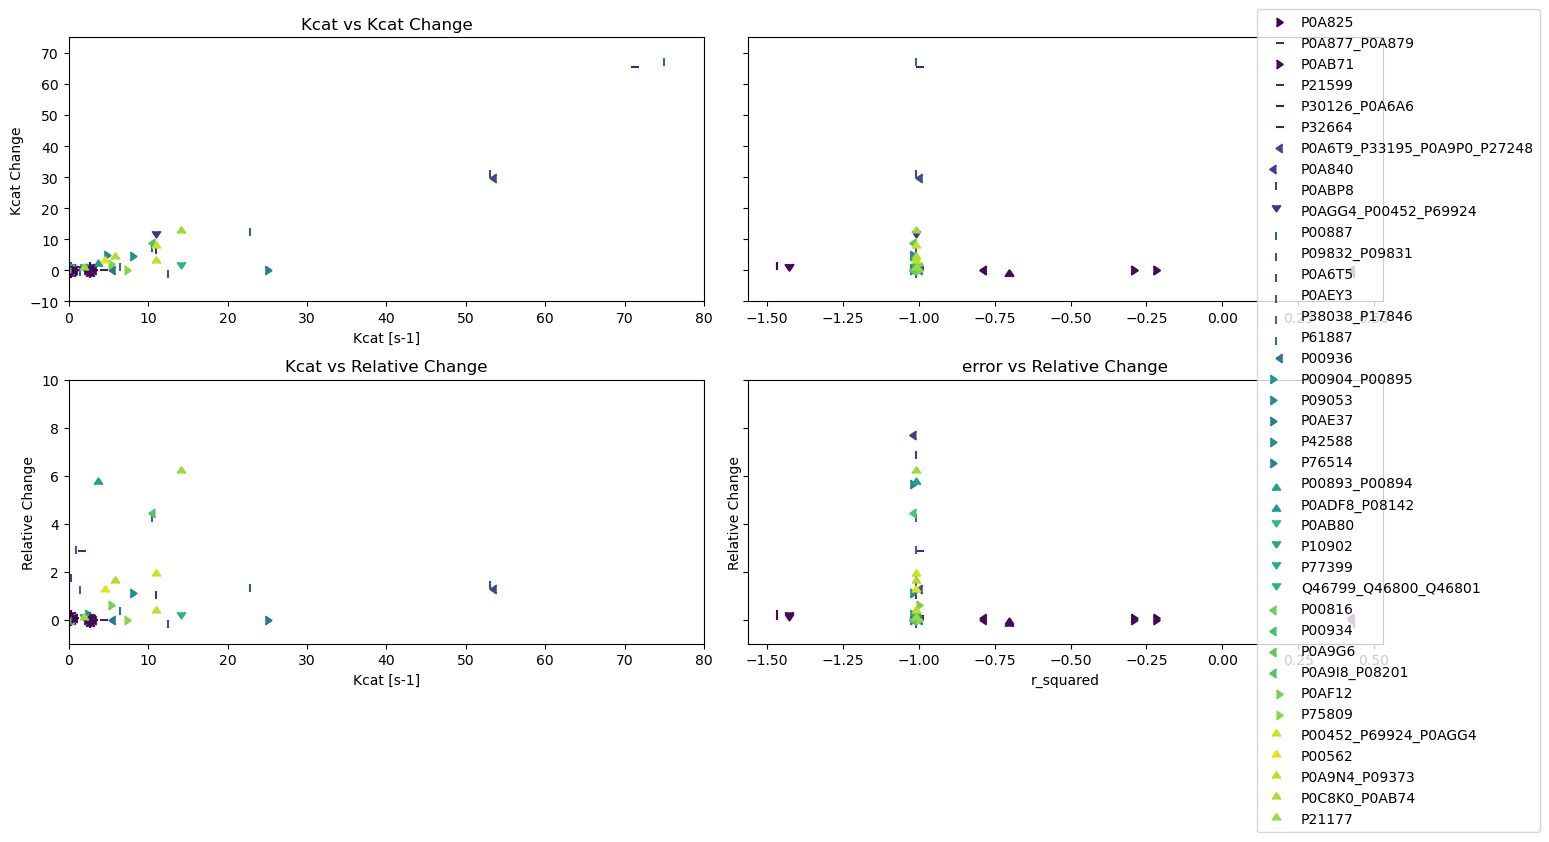

In [105]:
config = best_indiv_all_rounds_diff_kcat.iloc[0]['binned']

fig, axs = plt.subplots(ncols=len(result_file_names)+1,nrows = 2, sharey='row',figsize=(14, 7), dpi=100)
for iteration, best_indiv_df in best_indiv_grouped:
    row_index = 0
    for enzyme_id, enzyme_data in best_indiv_df.groupby('enzyme_id'):
        color = enzyme_to_color[enzyme_id]
        
        # Plot for kcat_change
        axs[row_index, 0].scatter(enzyme_data['kcat[s-1]'], enzyme_data['kcat_change'], 
                                  color=color, marker=iteration, label=f'{enzyme_id}')
        axs[row_index, 1].scatter(enzyme_data['r_squared'], enzyme_data['kcat_change'], 
                                  color=color, marker=iteration, label=f'{enzyme_id}')
        
        # Plot for relative_change
        axs[row_index + 1, 0].scatter(enzyme_data['kcat[s-1]'], enzyme_data['relative_change'], 
                                      color=color, marker=iteration, label=f'{enzyme_id}')
        
        # Plot for relative_change
        axs[row_index + 1, 1].scatter(enzyme_data['r_squared'], enzyme_data['relative_change'], 
                                      color=color, marker=iteration, label=f'{enzyme_id}')

# Set titles and labels
axs[0, 0].set_title('Kcat vs Kcat Change')
axs[0, 0].set_xlabel('Kcat [s-1]')
axs[0, 0].set_ylabel('Kcat Change')
axs[0, 0].set_ylim([-10,75])
axs[0, 0].set_xlim([0,80])

axs[1, 0].set_title('Kcat vs Relative Change')
axs[1, 0].set_xlabel('Kcat [s-1]')
axs[1, 0].set_ylabel('Relative Change')
axs[1, 1].set_title('error vs Relative Change')
axs[1, 1].set_xlabel('r_squared')
axs[1, 1].set_ylabel('Relative Change')

axs[1, 0].set_ylim([-1,10])
axs[1, 0].set_xlim([0,80])

# Create legends
handles, labels = axs[1, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()



### 3.2 Overview as lineplot

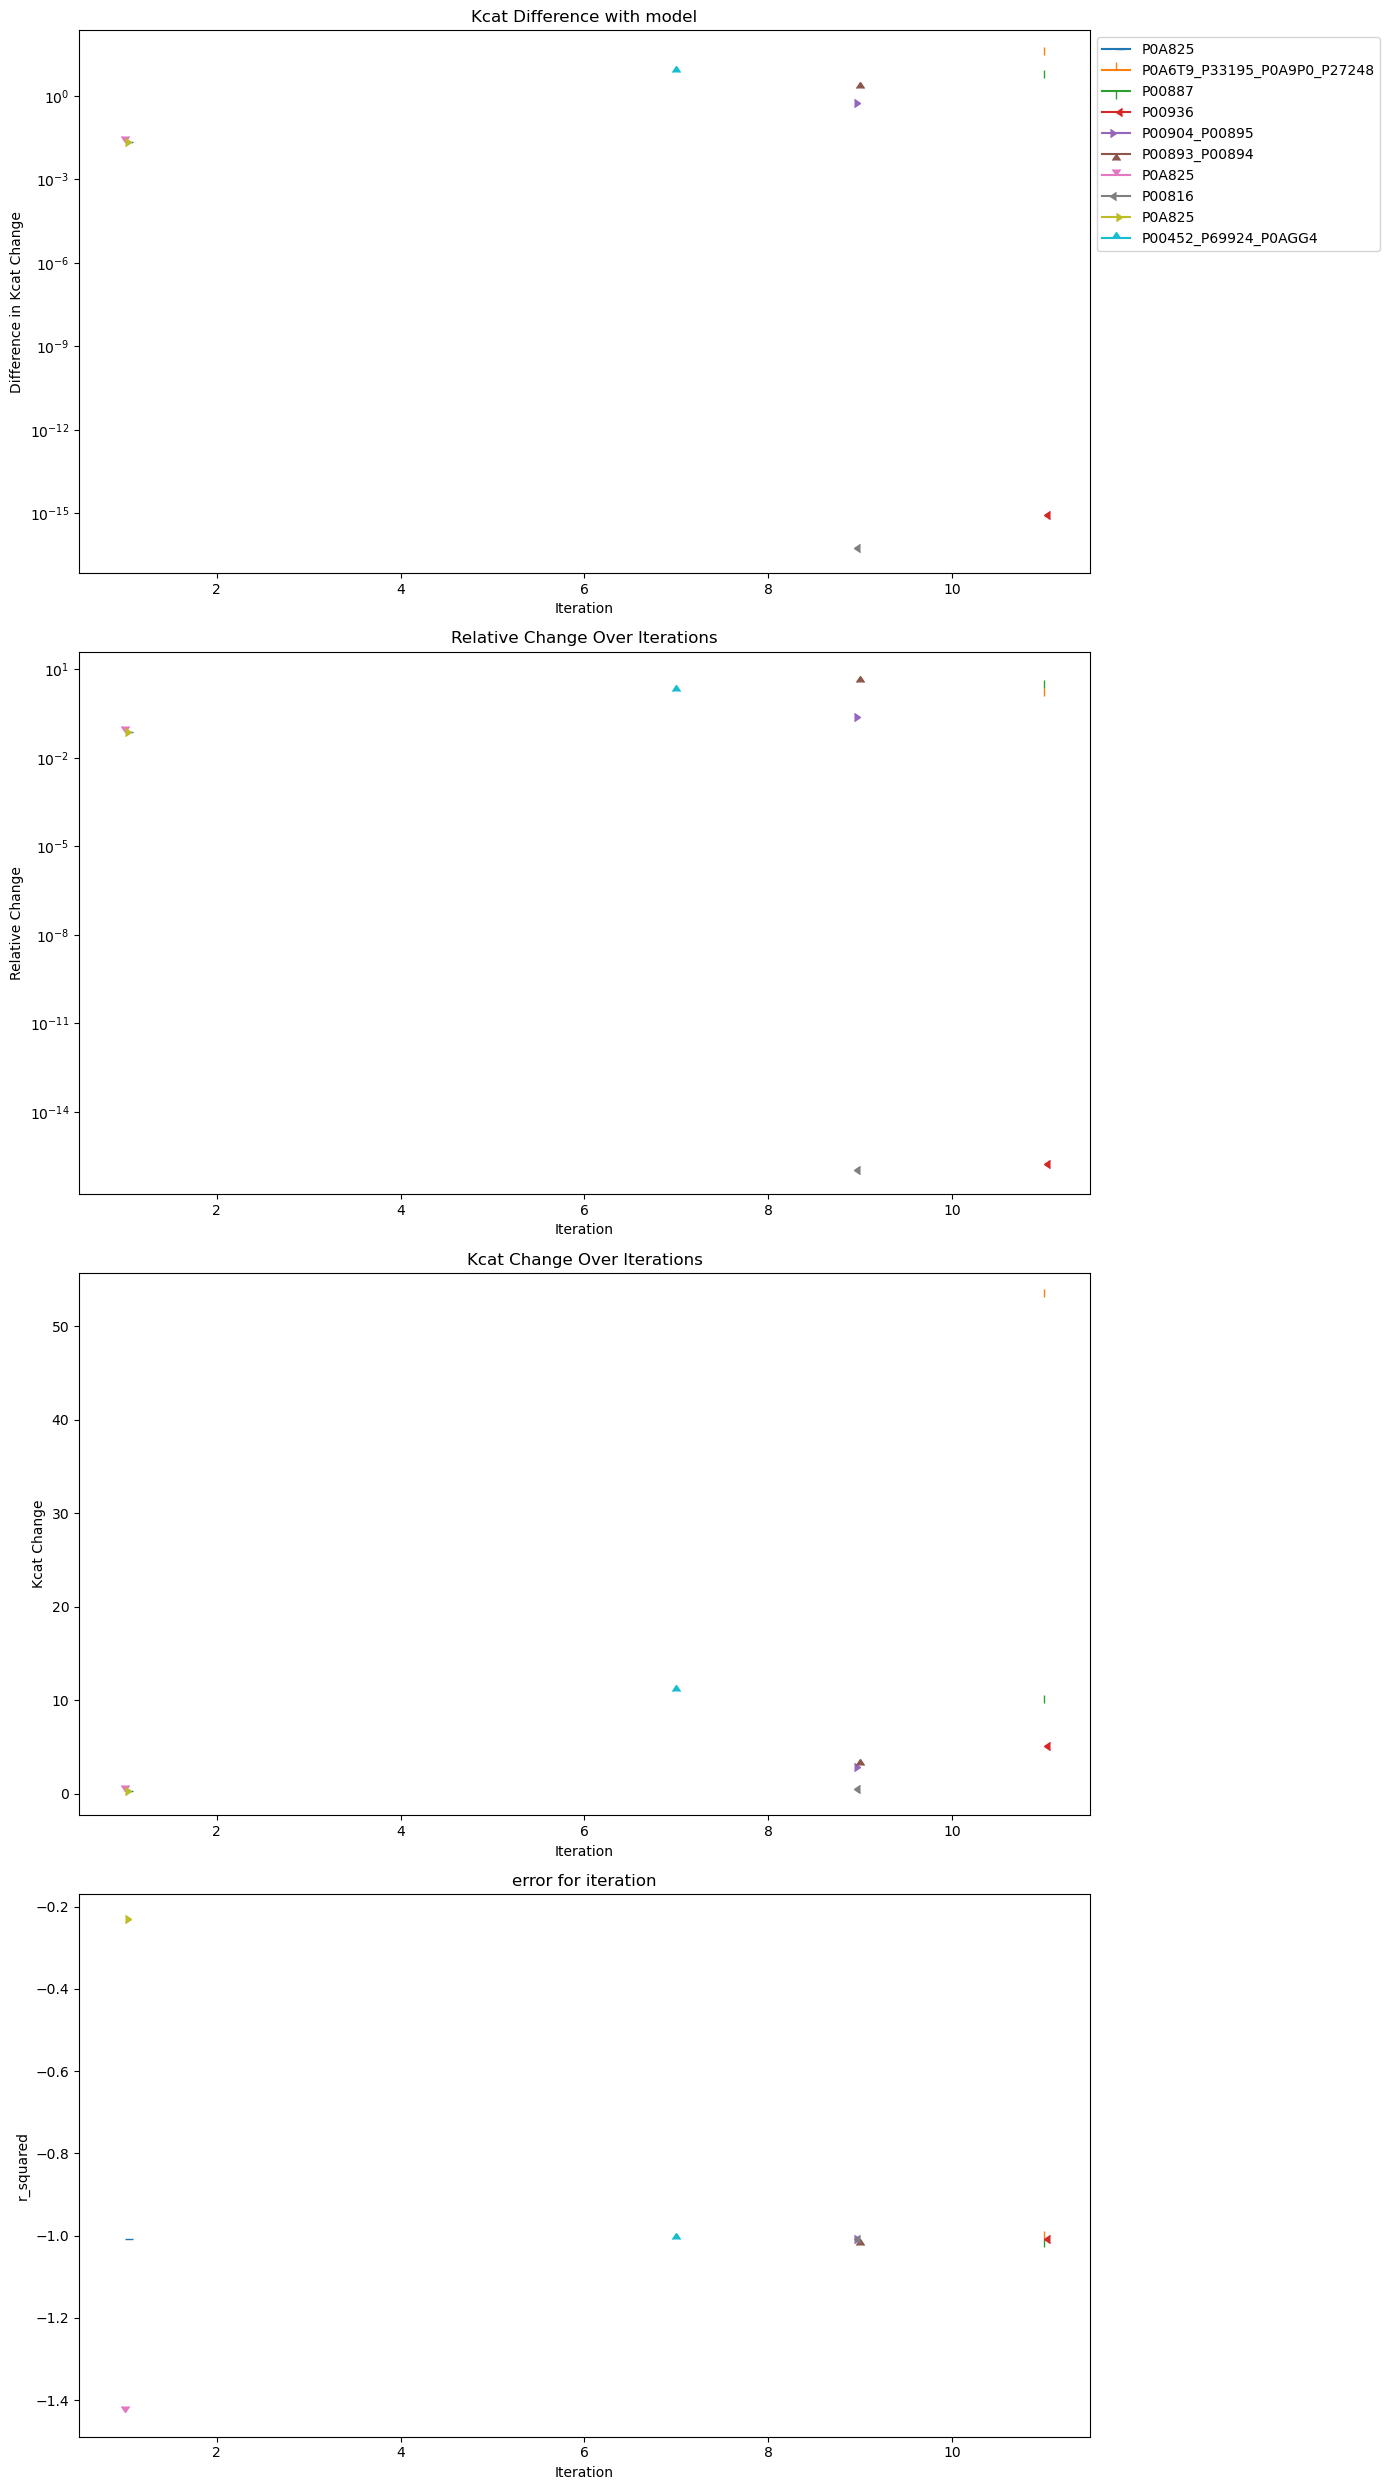

In [106]:
fig, axs = plt.subplots(4, 1, figsize=(14, 25), dpi=100)

# Line plot for kcat_change
for iteration, best_indiv_df in best_indiv_grouped:
    for enzyme_id, enzyme_data in best_indiv_df.groupby('enzyme_id'):
        axs[0].plot(enzyme_data['run_id'], enzyme_data['kcat_change'], marker=iteration, label=enzyme_id)
        axs[0].set_xlabel('Iteration')
        axs[0].set_ylabel('Difference in Kcat Change')
        axs[0].set_title('Kcat Difference with model')
        axs[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

        # Line plot for relative_change
        axs[1].plot(enzyme_data['run_id'], enzyme_data['relative_change'], marker=iteration, label=enzyme_id)
        axs[1].set_xlabel('Iteration')
        axs[1].set_ylabel('Relative Change')
        axs[1].set_title('Relative Change Over Iterations')
    #     axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1))

        axs[2].plot(enzyme_data['run_id'], enzyme_data['kcat[s-1]'], marker=iteration, label=enzyme_id)
        axs[2].set_xlabel('Iteration')
        axs[2].set_ylabel('Kcat Change')
        axs[2].set_title('Kcat Change Over Iterations')
    #     axs[2].legend(loc='upper left', bbox_to_anchor=(1, 1))
    
        axs[3].plot(enzyme_data['run_id'], enzyme_data['r_squared'], marker=iteration, label=enzyme_id)
        axs[3].set_xlabel('Iteration')
        axs[3].set_ylabel('r_squared')
        axs[3].set_title('error for iteration')
        break

axs[0].set_yscale('log')

axs[1].set_yscale('log')
plt.tight_layout()
plt.show()


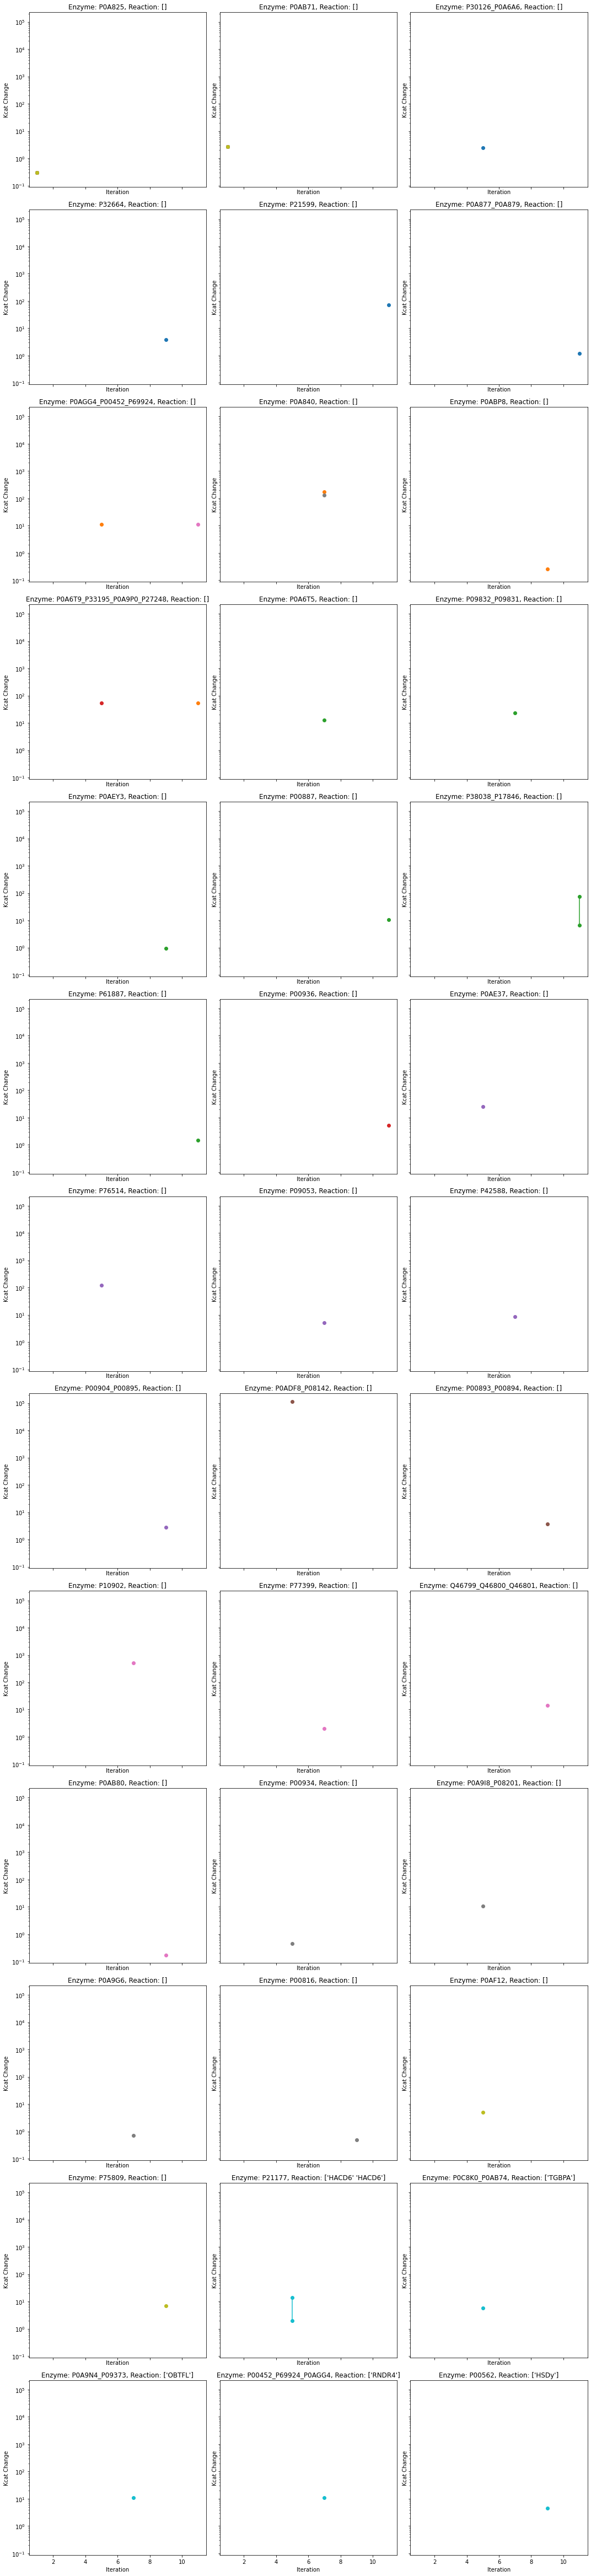

In [110]:
#per enzyme
# Set up the plot grid
n_rows = int(np.ceil(len(all_enzymes) / 3))
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), sharex=True, sharey=True)
axs = axs.flatten()

# Plot each enzyme
for iteration, best_indiv_df in best_indiv_grouped:
    for i, enzyme in enumerate(all_enzymes):
        enzyme_data = best_indiv_df[best_indiv_df['enzyme_id'] == enzyme]
        axs[i].plot(enzyme_data['run_id'], enzyme_data['kcat[s-1]'], marker='o')
        axs[i].set_title(f'Enzyme: {enzyme}, Reaction: {enzyme_data["rxn_id"].values}')
        axs[i].set_xlabel('Iteration')
        axs[i].set_ylabel('Kcat Change')
        axs[i].set_yscale('log')

# Remove any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

### 3.3 Heatmap

/tmp/ipykernel_11501/3193546929.py:6: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = best_indiv_all_rounds_diff_kcat.drop_duplicates().pivot(["iteration", 'run_id'],


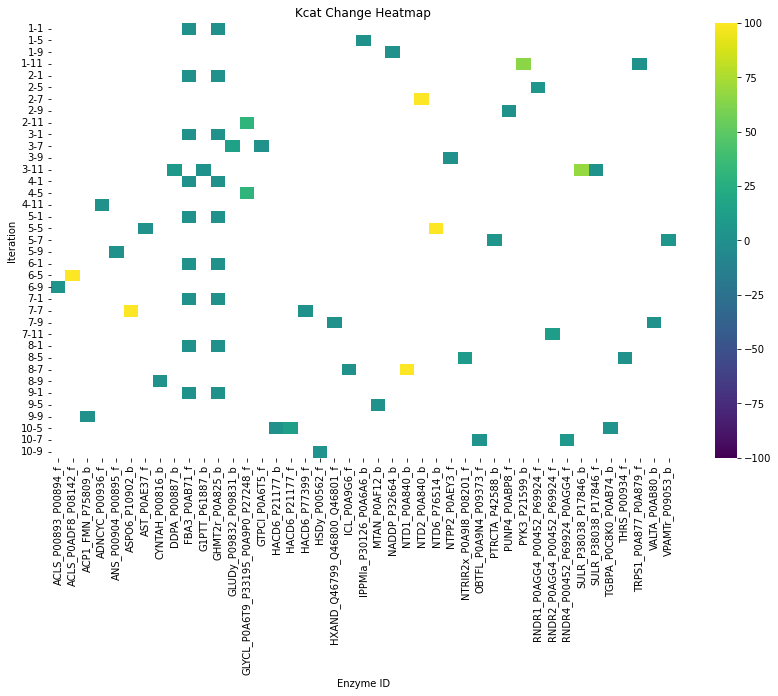

In [111]:
import seaborn as sns
from matplotlib.colors import LogNorm
# Pivot the dataframe for heatmap plotting
best_indiv_all_rounds_diff_kcat['id'] = best_indiv_all_rounds_diff_kcat.apply(
    lambda row: f"{row['rxn_id']}_{row['enzyme_id']}_{row['direction']}", axis=1)
heatmap_data = best_indiv_all_rounds_diff_kcat.drop_duplicates().pivot(["iteration", 'run_id'], 
                                                                                  "id", "kcat_change")
# heatmap_data = heatmap_data.replace(0, np.nan)
# heatmap_data = heatmap_data.fillna(1e-6)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="viridis",vmin = -100, vmax = 100)
plt.title('Kcat Change Heatmap')
plt.xlabel('Enzyme ID')
plt.ylabel('Iteration')
plt.show()

### 3.4 Bargraph

/tmp/ipykernel_11501/2909526917.py:4: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for run_id, best_indiv in best_indiv_all_rounds_diff_kcat.groupby(['run_id']):


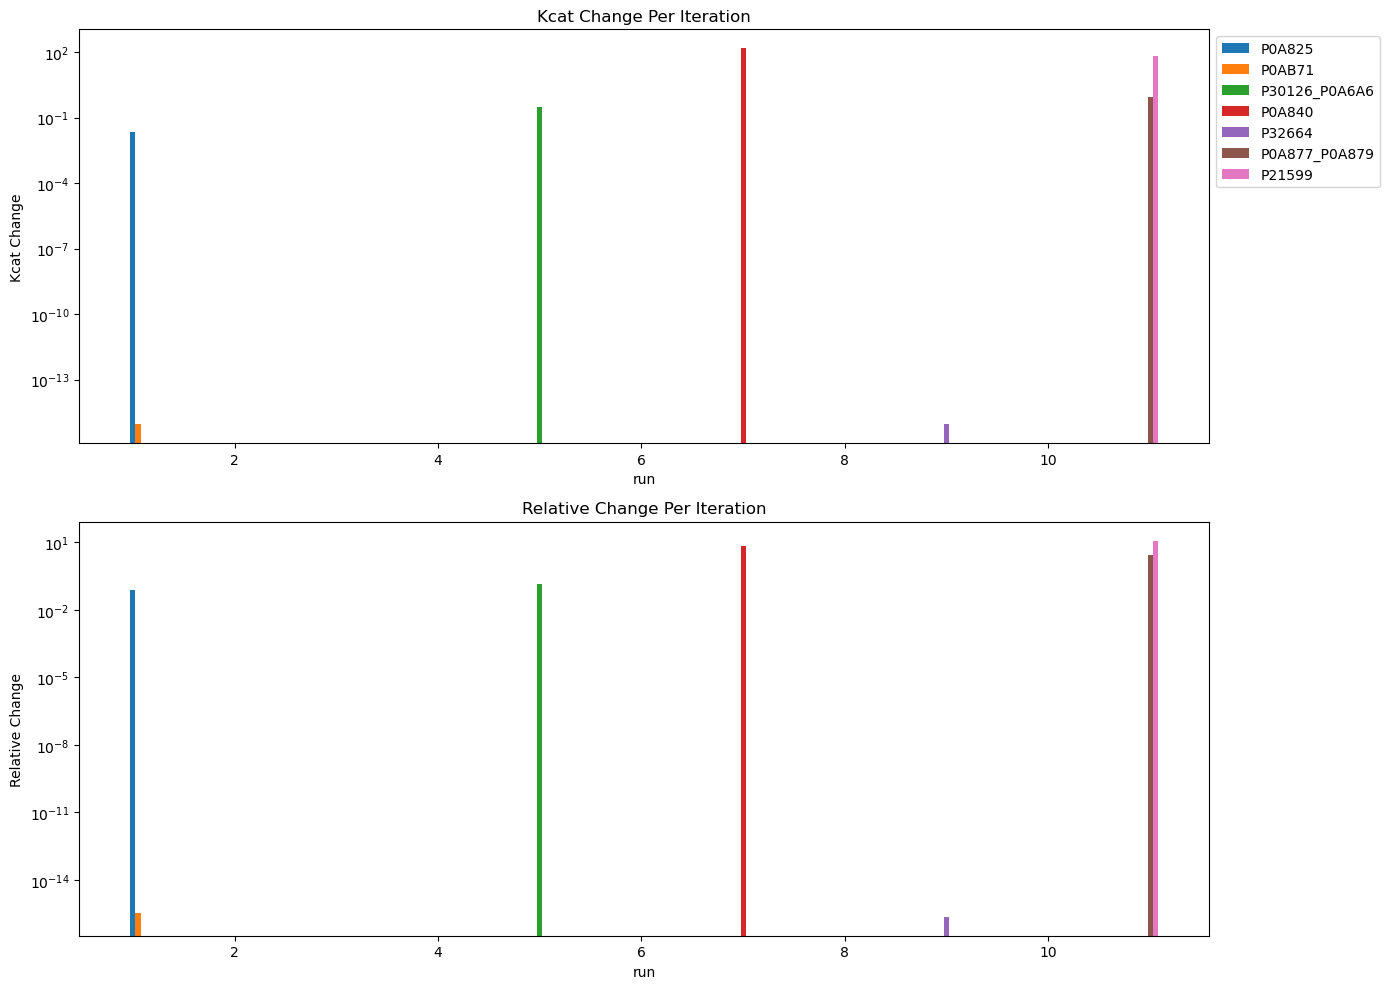

In [112]:
fig, axs = plt.subplots(2, 1, figsize=(14, 10), dpi=100)

# Bar plot for kcat_change
for run_id, best_indiv in best_indiv_all_rounds_diff_kcat.groupby(['run_id']):
    multiplier = 0
    width = 0.05
    for iteration, best_indiv_df in best_indiv.groupby('iteration'):
        for enzyme_id, enzyme_data in best_indiv_df.groupby('enzyme_id'):
            axs[0].bar(enzyme_data['run_id']+width*multiplier, enzyme_data['kcat_change'], width = width, label=enzyme_id)
            axs[0].set_xlabel('run')
            axs[0].set_ylabel('Kcat Change')
            axs[0].set_title('Kcat Change Per Iteration')
            axs[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
            axs[0].set_yscale('log')

            axs[1].bar(enzyme_data['run_id']+width*multiplier, enzyme_data['relative_change'], width = width, label=enzyme_id)
            axs[1].set_xlabel('run')
            axs[1].set_ylabel('Relative Change')
            axs[1].set_title('Relative Change Per Iteration')
    #         axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
            axs[1].set_yscale('log')
            multiplier += 1
        break
        
plt.tight_layout()
plt.show()


## 4. Study changes of all enzymes after parametrization
### 4.1 Get all changed enzymes

In [113]:
#only keep the datapoints until max rsuared is reached
max_r_squared_data = pd.DataFrame()
grouped = best_indiv_all_rounds.groupby('iteration')
for name, group in grouped:
    max_r_squared_row = group.loc[group['r_squared'].idxmax()]
    max_run_id = max_r_squared_row['run_id']
        
    subset = group[group['run_id'] <= max_run_id]
    max_r_squared_data = pd.concat([max_r_squared_data, subset])

max_r_squared_data

,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction
0,1,False,1,P0A825,GHMT2r,0.2771,-1.008096,-1.008097,f
1,1,False,1,P0A825,GHMT2r,0.2984,-1.008096,-1.008097,b
2,1,False,1,P0AB71,FBA3,2.6495,-1.008096,-1.008097,f
3,1,False,1,P0AB71,FBA3,1.5402,-1.008096,-1.008097,b
4,1,False,1,P15640,PRAGSr,0.1706,-1.008096,-1.008097,f
...,...,...,...,...,...,...,...,...,...
546,10,False,9,P0AEK2,3OAR140,11.0000,-1.008096,-1.008097,f
547,10,False,9,P22259,PPCK,7.3877,-1.008096,-1.008097,f
548,10,False,9,P22259,PPCK,7.3877,-1.008096,-1.008097,b
549,10,False,9,P30147,HPYRI,44.5824,-1.008096,-1.008097,f


In [114]:
best_indiv_all_rounds_last_value = max_r_squared_data.drop_duplicates(['enzyme_id','rxn_id', 'iteration'], keep = 'last')
best_kcats_differences = best_indiv_all_rounds_last_value.groupby(
    'iteration').apply(calculate_kcat_differences).reset_index(drop=True)
best_kcats_differences

,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction,previous_kcat,kcat_change,relative_change
0,1,False,3,P0A9N4_P09373_P68066,OBTFL,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00
1,1,False,3,P0A9P4_P0AA25,TRDR,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00
2,1,False,3,P22256,SDPTA,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00
3,1,False,5,P00634,3NTD7pp,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00
4,1,False,5,P0AB80,LEUTAi,0.1710,-1.008096,-1.008097,b,0.1710,8.326673e-17,4.869399e-16
...,...,...,...,...,...,...,...,...,...,...,...,...
104,10,False,8,P25516,ACONTb,4.4574,-1.008096,-1.008097,b,4.4574,0.000000e+00,0.000000e+00
105,10,False,9,P00562,HSDy,2.1410,-1.008096,-1.008097,b,2.1410,0.000000e+00,0.000000e+00
106,10,False,9,P0AEK2,3OAR140,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00
107,10,False,9,P22259,PPCK,7.3877,-1.008096,-1.008097,b,7.3877,0.000000e+00,0.000000e+00


### 4.2 plots

KeyError: 'P00634'

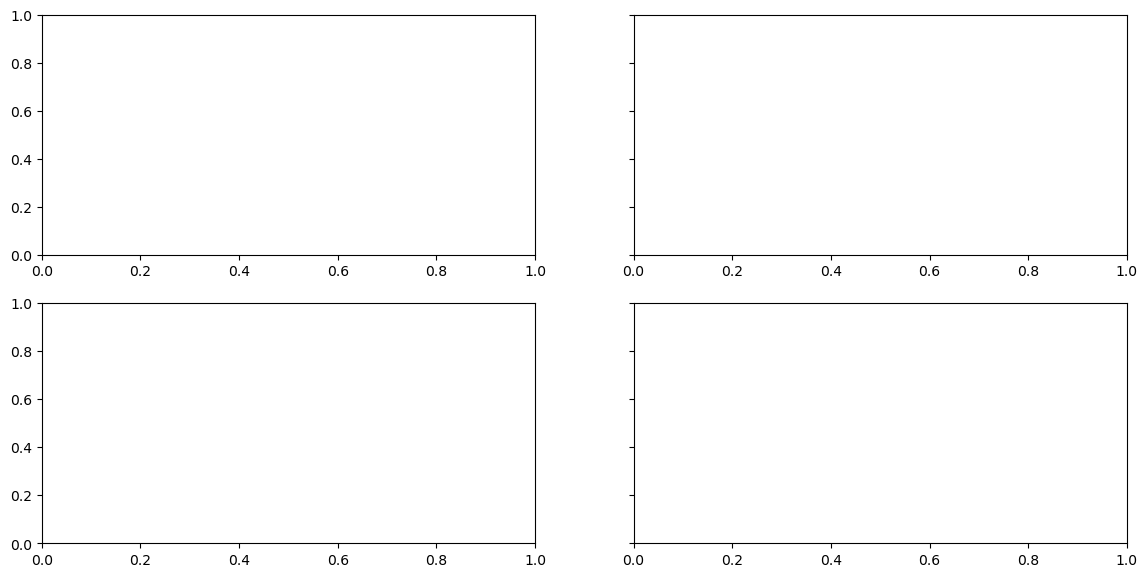

In [115]:
config = best_kcats_differences.iloc[0]['binned']

fig, axs = plt.subplots(ncols=len(result_file_names)+1,nrows = 2, sharey='row',figsize=(14, 7), dpi=100)
for iteration, best_indiv_df in best_kcats_differences.groupby('iteration'):
    row_index = 0
    for enzyme_id, enzyme_data in best_indiv_df.groupby('enzyme_id'):
        color = enzyme_to_color[enzyme_id]
        
        # Plot for kcat_change
        axs[row_index, 0].scatter(enzyme_data['kcat[s-1]'], enzyme_data['kcat_change'], 
                                  color=color, marker=iteration, label=f'{enzyme_id}')
        axs[row_index, 1].scatter(enzyme_data['r_squared'], enzyme_data['kcat_change'], 
                                  color=color, marker=iteration, label=f'{enzyme_id}')
        
        # Plot for relative_change
        axs[row_index + 1, 0].scatter(enzyme_data['kcat[s-1]'], enzyme_data['relative_change'], 
                                      color=color, marker=iteration, label=f'{enzyme_id}')
        
        # Plot for relative_change
        axs[row_index + 1, 1].scatter(enzyme_data['r_squared'], enzyme_data['relative_change'], 
                                      color=color, marker=iteration, label=f'{enzyme_id}')

# Set titles and labels
axs[0, 0].set_title('Kcat vs Kcat Change')
axs[0, 0].set_xlabel('Kcat [s-1]')
axs[0, 0].set_ylabel('Kcat Change')
axs[0, 0].set_ylim([-100,100])
axs[0, 0].set_xlim([0,50])

axs[1, 0].set_title('Kcat vs Relative Change')
axs[1, 0].set_xlabel('Kcat [s-1]')
axs[1, 0].set_ylabel('Relative Change')
axs[1, 1].set_title('error vs Relative Change')
axs[1, 1].set_xlabel('r_squared')
axs[1, 1].set_ylabel('Relative Change')

axs[1, 0].set_ylim([-10,10])
axs[1, 0].set_xlim([0,50])

# Create legends
handles, labels = axs[1, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()



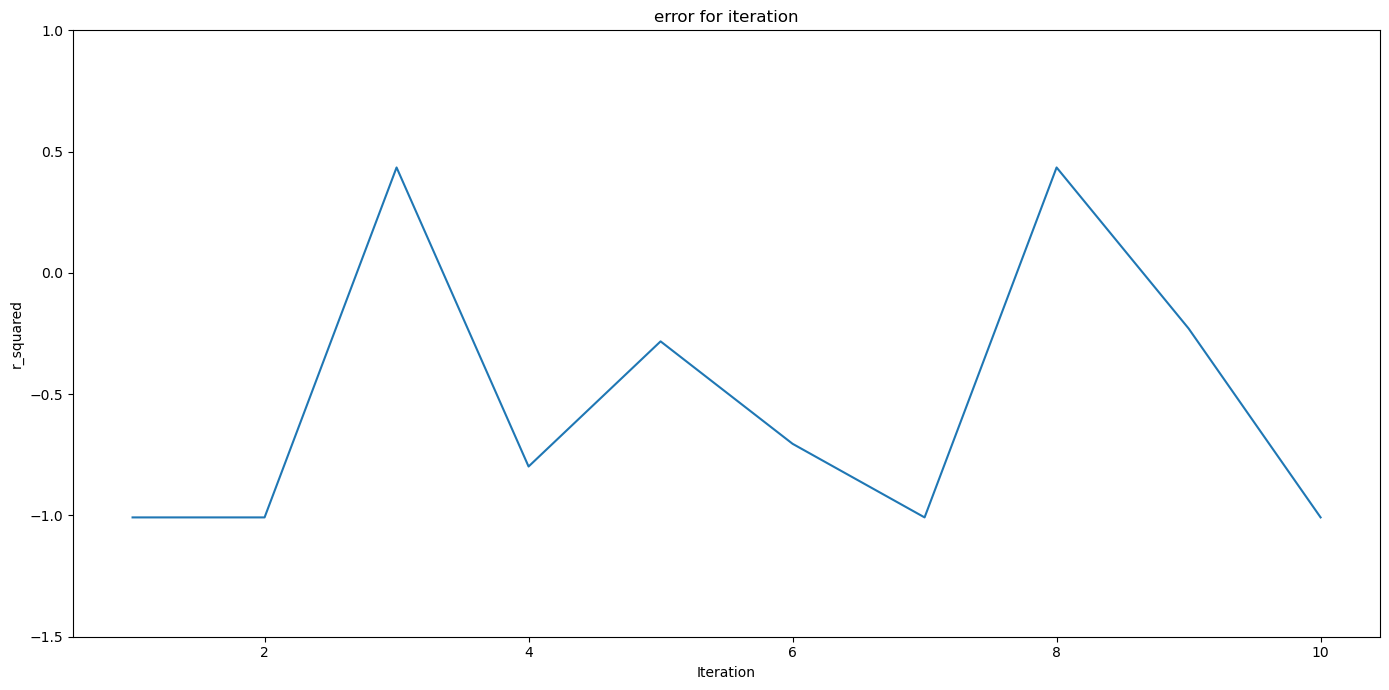

In [116]:
fig, axs = plt.subplots(1, 1, figsize=(14,7), dpi=100)
best_indiv_iteration_rsquared = best_kcats_differences.drop_duplicates(
    ['iteration'], keep = 'last').reset_index(drop=True)

# Line plot for error
axs.plot(best_indiv_iteration_rsquared['iteration'], best_indiv_iteration_rsquared['r_squared'])
axs.set_xlabel('Iteration')
axs.set_ylabel('r_squared')
axs.set_title('error for iteration')
axs.set_ylim(-1.5, 1)

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


     iteration  binned  run_id enzyme_id  rxn_id  kcat[s-1]  ga_error  \
10           1   False       8    P0A825  GHMT2r     0.2984 -1.008096   
25           2   False       8    P0A825  GHMT2r     0.2984 -1.469233   
33           3   False       4    P0A825  GHMT2r     0.2984  0.434630   
45           4   False       8    P0A825  GHMT2r     0.2984 -0.798254   
49           5   False       1    P0A825  GHMT2r     0.2984 -0.282334   
65           6   False      10    P0A825  GHMT2r     0.2984 -0.704615   
77           7   False       8    P0A825  GHMT2r     0.2984 -1.429041   
85           8   False       4    P0A825  GHMT2r     0.2984  0.434630   
89           9   False       4    P0A825  GHMT2r     0.2984 -0.229206   
101         10   False       8    P0A825  GHMT2r     0.2984 -1.008096   

     r_squared direction  previous_kcat  kcat_change  relative_change  
10   -1.008097         b         0.2984          0.0              0.0  
25   -1.469234         b         0.2984          0.0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

    iteration  binned  run_id      enzyme_id rxn_id  kcat[s-1]  ga_error  \
75          7   False       7  P38038_P17846   FLVR       11.0 -1.429041   

    r_squared direction  previous_kcat  kcat_change  relative_change  
75  -1.008097         f           11.0          0.0              0.0  
    iteration  binned  run_id      enzyme_id  rxn_id  kcat[s-1]  ga_error  \
82          7   False       9  P38038_P17846  FMNRx2       11.0 -1.429041   

    r_squared direction  previous_kcat  kcat_change  relative_change  
82  -1.008097         f           11.0          0.0              0.0  
    iteration  binned  run_id      enzyme_id rxn_id  kcat[s-1]  ga_error  \
54          6   False       5  P0ADF8_P08142   ACLS     3.7417 -0.704615   

    r_squared direction  previous_kcat  kcat_change  relative_change  
54  -1.008097         b         3.7417          0.0              0.0  


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


    iteration  binned  run_id      enzyme_id rxn_id  kcat[s-1]  ga_error  \
61          6   False       9  P00893_P00894   ACLS     3.7417 -0.704615   

    r_squared direction  previous_kcat  kcat_change  relative_change  
61  -1.008097         b         3.7417          0.0              0.0  
    iteration  binned  run_id enzyme_id rxn_id  kcat[s-1]  ga_error  \
73          7   False       7    P10902  ASPO6   517.9597 -1.429041   

    r_squared direction  previous_kcat  kcat_change  relative_change  
73  -1.008097         b       517.9597          0.0              0.0  
    iteration  binned  run_id enzyme_id rxn_id  kcat[s-1]  ga_error  \
76          7   False       7    P77399  HACD6     1.9743 -1.429041   

    r_squared direction  previous_kcat   kcat_change  relative_change  
76  -1.008097         b         1.9743  1.110223e-15     5.623375e-16  
    iteration  binned  run_id             enzyme_id rxn_id  kcat[s-1]  \
84          7   False       9  Q46799_Q46800_Q46801  HXAND  

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


    iteration  binned  run_id enzyme_id rxn_id  kcat[s-1]  ga_error  \
74          7   False       7    P21177  HACD1     2.0611 -1.429041   

    r_squared direction  previous_kcat  kcat_change  relative_change  
74  -1.008097         b         2.0611          0.0              0.0  
    iteration  binned  run_id enzyme_id rxn_id  kcat[s-1]  ga_error  \
95         10   False       5    P21177  HACD6     1.9743 -1.008096   

    r_squared direction  previous_kcat   kcat_change  relative_change  
95  -1.008097         b         1.9743  1.110223e-15     5.623375e-16  
    iteration  binned  run_id enzyme_id rxn_id  kcat[s-1]  ga_error  \
59          6   False       7    P21177  HACD7     1.9131 -0.704615   

    r_squared direction  previous_kcat  kcat_change  relative_change  
59  -1.008097         b         1.9131          0.0              0.0  
    iteration  binned  run_id      enzyme_id rxn_id  kcat[s-1]  ga_error  \
94         10   False       5  P0C8K0_P0AB74  TGBPA     5.8427 -1.0

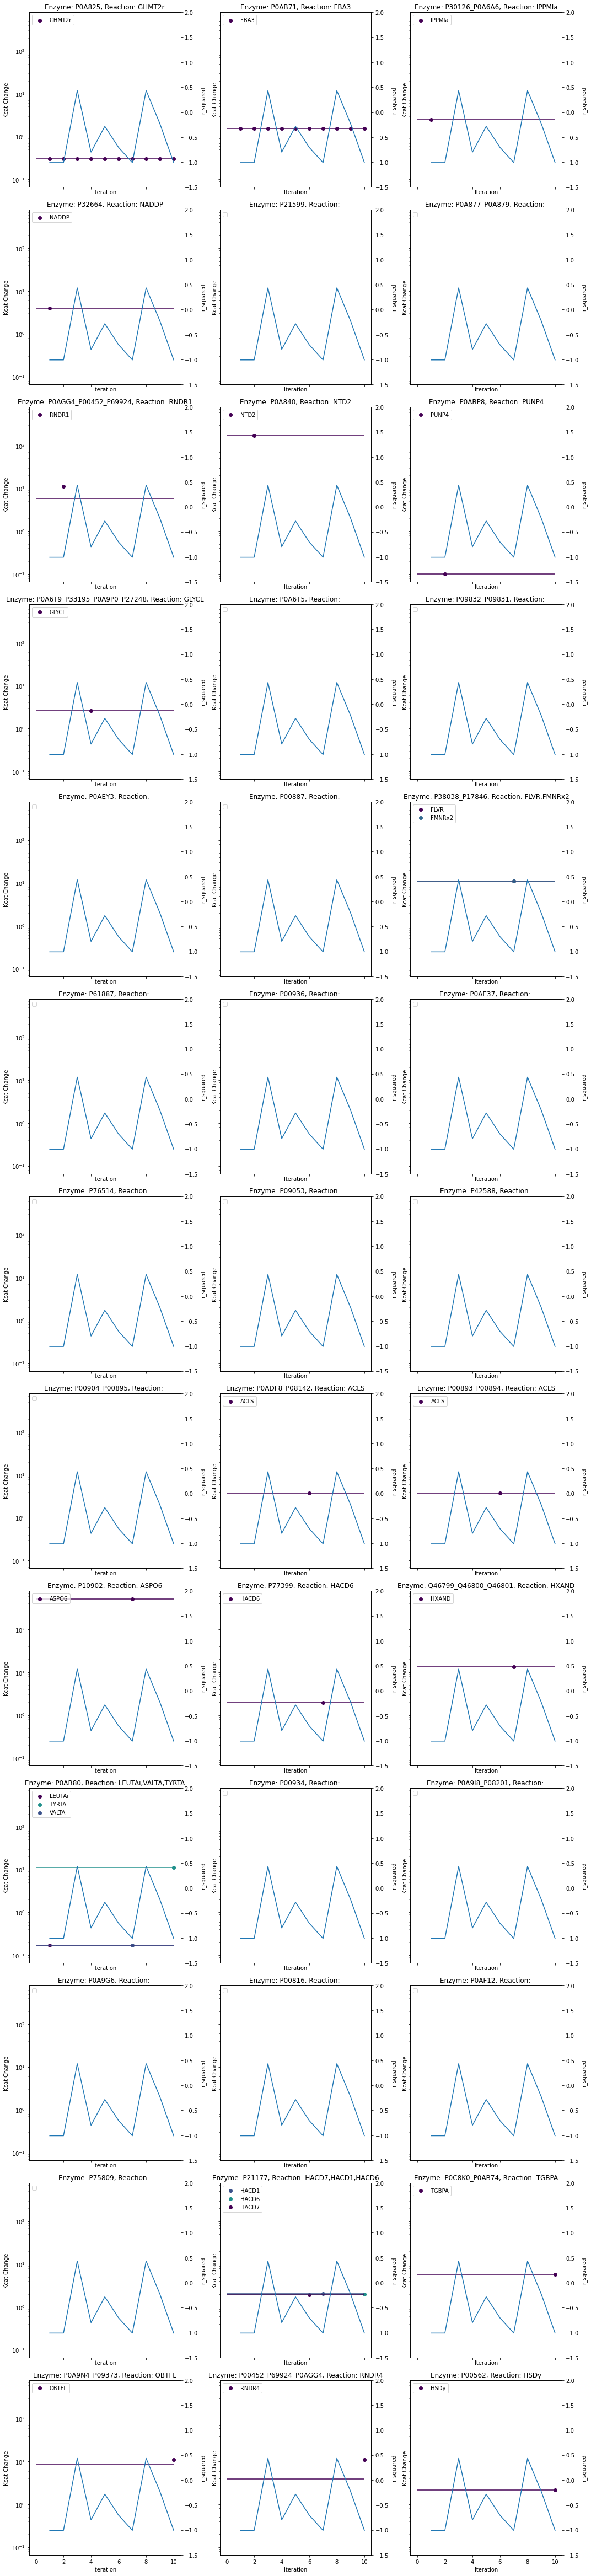

In [117]:
#per enzyme

# Set up the plot grid
n_rows = int(np.ceil(len(all_enzymes) / 3))
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), sharex=True, sharey=True)
axs = axs.flatten()

# Plot each enzyme
for i, enzyme in enumerate(all_enzymes):
    enzyme_data = best_kcats_differences[best_kcats_differences['enzyme_id'] == enzyme]
    rxns = enzyme_data.rxn_id.unique()
    rxn_to_color = {rxn:to_hex(cmap(i / (len(rxns) + 1))) for i, rxn in enumerate(rxns)}
    for rxn, data in enzyme_data.groupby('rxn_id'):
        print(data)
        axs[i].scatter(data['iteration'], data['kcat[s-1]'], marker='o', color = rxn_to_color[rxn], label=rxn)
    
    #create reference line for original value
        row = data.iloc[0]
        enzyme_kcat = rxn2kcat[row['rxn_id']][row['enzyme_id']][row['direction']]

        axs[i].hlines(y = enzyme_kcat, xmin = 0, xmax=10, color = rxn_to_color[rxn])
    
    axs[i].legend(loc='upper left')
    
    axs[i].set_title(f'Enzyme: {enzyme}, Reaction: {",".join(enzyme_data["rxn_id"].drop_duplicates().to_list())}')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel('Kcat Change')
    axs[i].set_yscale('log')
    ax2 = axs[i].twinx()
    ax2.plot(best_indiv_iteration_rsquared['iteration'], best_indiv_iteration_rsquared['r_squared'])
    ax2.set_ylabel('r_squared')
    ax2.set_ylim([-1.5, 2])
    

# Remove any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [118]:
from matplotlib.colors import LogNorm
heatmap_data = best_kcats_differences.pivot(["iteration"], "rxn_id", "kcat[s-1]")
# heatmap_data = heatmap_data.replace(0, np.nan)
# heatmap_data = heatmap_data.fillna(1e-6)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="viridis", norm = LogNorm())#,vmin = -100, vmax = 100)
plt.title('Kcat result Heatmap')
plt.xlabel('Enzyme ID')
plt.ylabel('Iteration')
plt.show()

/tmp/ipykernel_11501/669130541.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = best_kcats_differences.pivot(["iteration"], "rxn_id", "kcat[s-1]")


ValueError: Index contains duplicate entries, cannot reshape

### 5. Changes per pathway

In [119]:
# get pathway information from genelist file
gene_list_info = pd.read_excel(os.path.join('Data', 'GeneList_ecoli.xlsx'), sheet_name = 'GeneList')
rxn2gene_info = pd.read_excel(os.path.join('Data', 'GeneList_ecoli.xlsx'), sheet_name = 'gene2rxn')

In [122]:
# map cog information to reactions using the gene id
gene2rxn2cog = pd.merge(gene_list_info[['bnumber', 'COG description']], rxn2gene_info,
                       left_on = 'bnumber', right_on = 'Gene', how = 'inner')
gene2rxn2cog.Reactions = gene2rxns2cog.Reactions.str.split(', ')
gene2rxn2cog['COG description'] = gene2rxn2cog['COG description'].str.split(';')
gene2rxn2cog = gene2rxn2cog.explode('Reactions')
gene2rxn2cog = gene2rxn2cog.explode('COG description').reset_index(drop=True)

gene2rxn2cog

,bnumber,COG description,Gene,Reactions
0,b0002,Amino acid transport and metabolism,b0002,ASPK
1,b0002,Amino acid transport and metabolism,b0002,HSDy
2,b0003,Amino acid transport and metabolism,b0003,HSK
3,b0003,Amino acid transport and metabolism,b0003,HOSK
4,b0004,Amino acid transport and metabolism,b0004,THRS
...,...,...,...,...
5125,b4467,Energy production and conversion,b4467,GLYCTO2
5126,b4474,Carbohydrate transport and metabolism,b4474,FRLYSE
5127,b4477,Carbohydrate transport and metabolism,b4477,DDPGALA
5128,b4485,Carbohydrate transport and metabolism,b4485,RIBabcpp


In [123]:
# map cog information to changed enzymes using the reactions
best_kcats_with_cog = pd.merge(best_kcats_differences, gene2rxn2cog[['Reactions', 'COG description']],
                               left_on='rxn_id', right_on = 'Reactions', how='left')
best_kcats_with_cog = best_kcats_with_cog.drop_duplicates(
    ['rxn_id','enzyme_id', 'r_squared', 'COG description']).reset_index(drop=True)

best_kcats_with_cog

,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction,previous_kcat,kcat_change,relative_change,Reactions,COG description
0,1,False,3,P0A9N4_P09373_P68066,OBTFL,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00,OBTFL,"Posttranslational modification, protein turnov..."
1,1,False,3,P0A9N4_P09373_P68066,OBTFL,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00,OBTFL,Energy production and conversion
2,1,False,3,P0A9N4_P09373_P68066,OBTFL,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00,OBTFL,Coenzyme transport and metabolism
3,1,False,3,P0A9P4_P0AA25,TRDR,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00,TRDR,"Posttranslational modification, protein turnov..."
4,1,False,3,P22256,SDPTA,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00,SDPTA,Amino acid transport and metabolism
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,10,False,8,P25516,ACONTb,4.4574,-1.008096,-1.008097,b,4.4574,0.000000e+00,0.000000e+00,ACONTb,Energy production and conversion
153,10,False,9,P00562,HSDy,2.1410,-1.008096,-1.008097,b,2.1410,0.000000e+00,0.000000e+00,HSDy,Amino acid transport and metabolism
154,10,False,9,P0AEK2,3OAR140,11.0000,-1.008096,-1.008097,f,11.0000,0.000000e+00,0.000000e+00,3OAR140,Lipid transport and metabolism
155,10,False,9,P22259,PPCK,7.3877,-1.008096,-1.008097,b,7.3877,0.000000e+00,0.000000e+00,PPCK,Energy production and conversion


In [125]:
# Calculate cumulative change of each COG category per iteration
best_kcats_change_per_cog = best_kcats_with_cog.groupby(['iteration', 'COG description'])['relative_change'].sum().reset_index()

# Calculate the absolute sum of relative changes per iteration
total_abs_change_per_iteration = best_kcats_with_cog.groupby('iteration')['relative_change'].sum().abs().reset_index()
total_abs_change_per_iteration.rename(columns={'relative_change': 'total_abs_change'}, inplace=True)

# Merge the cumulative changes with the total absolute changes
best_kcats_change_per_cog = pd.merge(best_kcats_change_per_cog, total_abs_change_per_iteration, on='iteration')

# Normalize the cumulative changes by the total absolute changes within each iteration
best_kcats_change_per_cog['normalized_relative_change'] =best_kcats_change_per_cog['relative_change'] / best_kcats_change_per_cog['total_abs_change']

best_kcats_change_per_cog

,iteration,COG description,relative_change,total_abs_change,normalized_relative_change
0,1,Amino acid transport and metabolism,3.625218e-16,1.302348e-15,2.783601e-01
1,1,Carbohydrate transport and metabolism,0.000000e+00,1.302348e-15,0.000000e+00
2,1,Coenzyme transport and metabolism,0.000000e+00,1.302348e-15,0.000000e+00
3,1,Defense mechanisms,0.000000e+00,1.302348e-15,0.000000e+00
4,1,Energy production and conversion,0.000000e+00,1.302348e-15,0.000000e+00
...,...,...,...,...,...
66,10,Coenzyme transport and metabolism,2.717351e-01,4.430315e+00,6.133539e-02
67,10,Energy production and conversion,2.717351e-01,4.430315e+00,6.133539e-02
68,10,Lipid transport and metabolism,5.623375e-16,4.430315e+00,1.269295e-16
69,10,Nucleotide transport and metabolism,1.807555e+00,4.430315e+00,4.079969e-01


In [126]:
# plot the relative changes
cog_descriptions = best_kcats_change_per_cog['COG description'].drop_duplicates().to_list()
cog2rxns = {}
for i, row in best_kcats_with_cog[['Reactions', 'COG description']].iterrows():
    cog = row['COG description']
    if cog in cog2rxns.keys():
        cog2rxns[cog] += [row.Reactions]
    else:
        cog2rxns[cog] = [row.Reactions]

In [130]:
counts_per_cog_iteration = best_kcats_with_cog.groupby(['COG description', 'iteration']).count()[['binned']]


binned
COG description                                    iteration        
Amino acid transport and metabolism                1               5
                                                   2               1
                                                   3               1
                                                   4               3
                                                   5               1
...                                                              ...
Posttranslational modification, protein turnove... 10              2
Replication, recombination and repair              1               1
                                                   2               1
Secondary metabolites biosynthesis, transport a... 2               1
Translation, ribosomal structure and biogenesis    4               1

[71 rows x 1 columns]

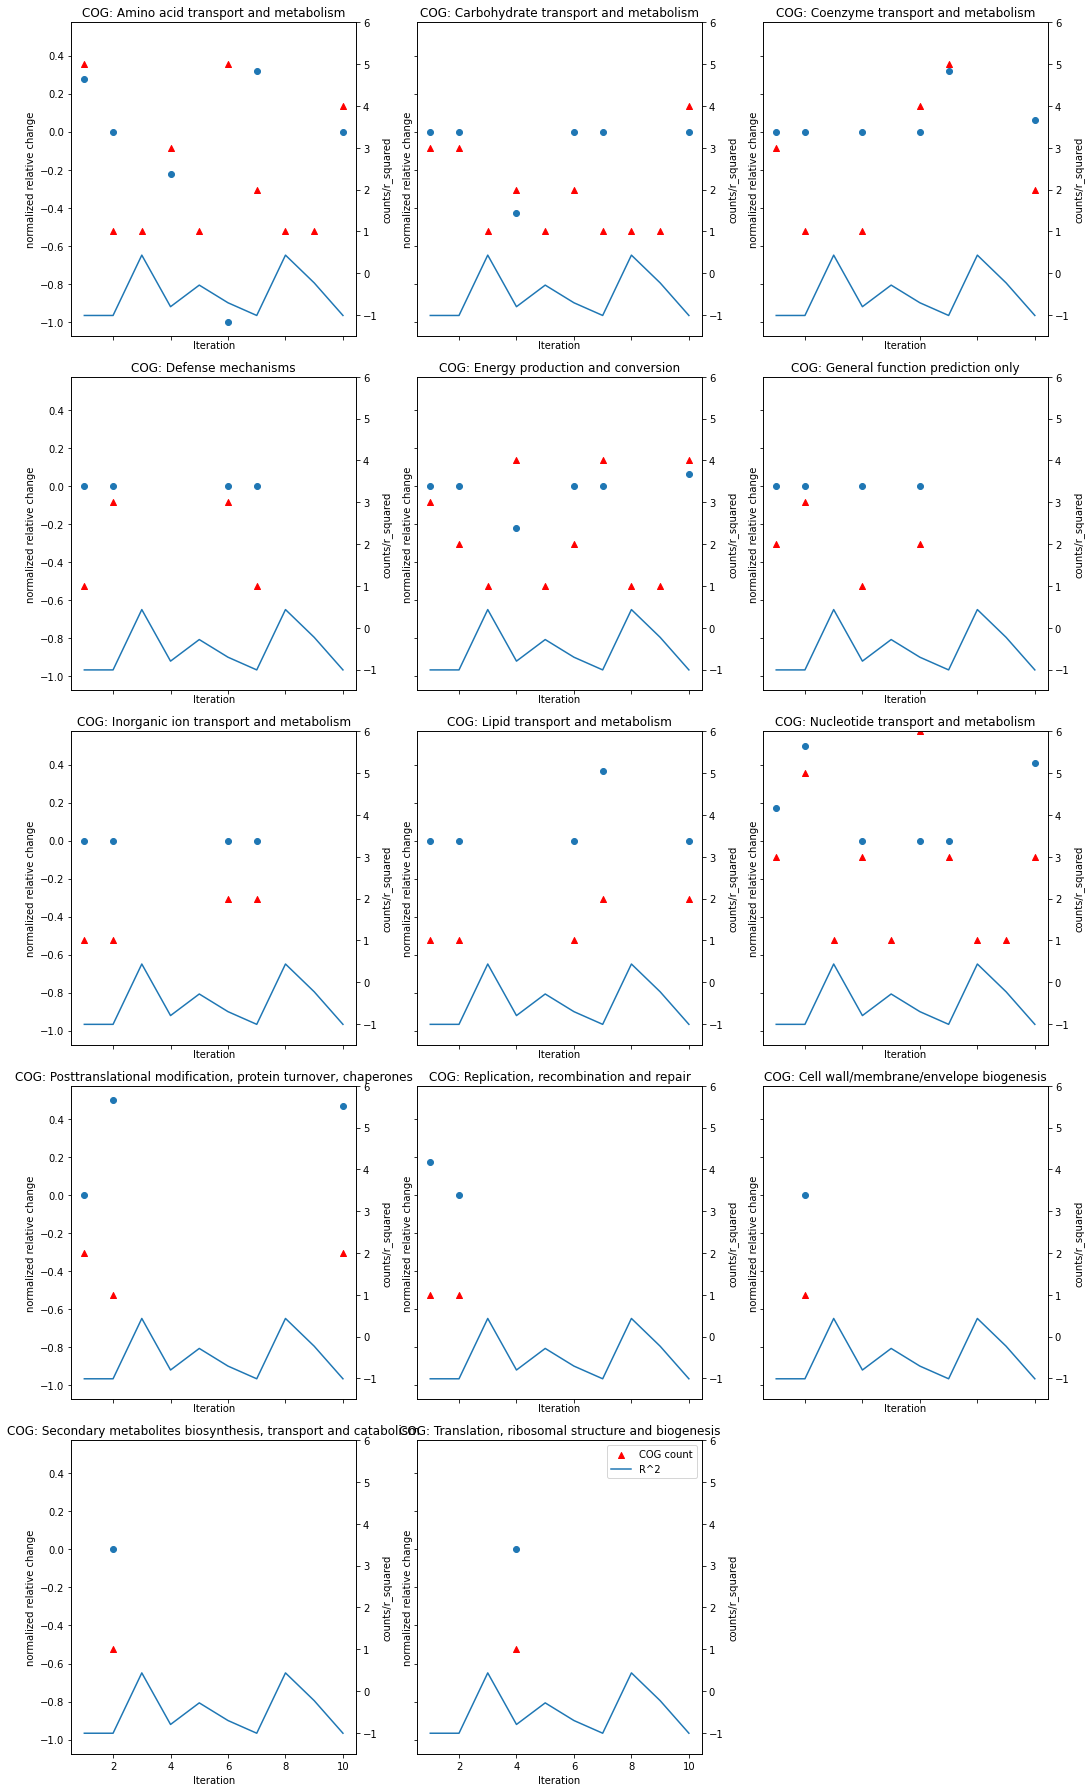

In [134]:
# Set up the plot grid
n_rows = int(np.ceil(len(cog_descriptions) / 3))
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), sharex=True, sharey=True)
axs = axs.flatten()

# Plot each enzyme
for i, cog in enumerate(cog_descriptions):
    cog_data = best_kcats_change_per_cog[best_kcats_change_per_cog['COG description'] == cog]
    axs[i].scatter(cog_data['iteration'], cog_data['normalized_relative_change'], marker='o',
                  label = 'relative change')
    
    #create reference line for original value
    axs[i].set_title(f'COG: {cog}')#, Reactions: {",".join(cog2rxns[cog])}')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel('normalized relative change')
#     axs[i].set_yscale('log')
    ax2 = axs[i].twinx()
    cog_counts = counts_per_cog_iteration.loc[cog]
    ax2.scatter(cog_counts.index, cog_counts.values, marker = '^', color = 'red', label = 'COG count')
    ax2.set_ylabel('counts/r_squared')
    ax2.plot(best_indiv_iteration_rsquared['iteration'], best_indiv_iteration_rsquared['r_squared'],
            label = 'R^2')
    ax2.set_ylim([-1.5, 6])
    

# Remove any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])
plt.legend()
plt.tight_layout()
plt.show()